In [1]:
# ================================
# Cell 0: Load dependencies & logs
# ================================
# 作用：
#   1. 加载 pandas / numpy / matplotlib
#   2. 读取你训练过程中保存的两类日志：
#      - training_logs.jsonl: sample-level（每一个生成样本）
#      - batch_summary.jsonl: batch-level（每一个训练 batch 的统计）
#
# 这是整个 notebook 的数据入口，后面的分析全部基于这两个 DataFrame。

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

eval: bool = False
batch: int = -1
plt.style.use("default")

# ⚠️ 改成你自己的 log 目录
log_dir = "/home/silas/co-scientist-project/runs/2026/4/best_ver_async/2"

if eval:
  LOG_DIR = f"{log_dir}/evaluation"
  sample_log_path = f"{LOG_DIR}/eval_logs({batch}).jsonl"
  batch_log_path  = f"{LOG_DIR}/eval_batch_summary({batch}).jsonl"
else:
  LOG_DIR = f"{log_dir}/train"
  sample_log_path = f"{LOG_DIR}/training_logs.jsonl"
  batch_log_path  = f"{LOG_DIR}/batch_summary.jsonl"

# sample-level：每一行是一个生成样本
df_samples = pd.read_json(sample_log_path, lines=True)

# batch-level：每一行是一个 batch 的统计
df_batch = pd.read_json(batch_log_path, lines=True)

print("Sample-level log shape:", df_samples.shape)
print("Batch-level log shape:", df_batch.shape)

# 快速 sanity check
df_batch.head()


Sample-level log shape: (10831, 10)
Batch-level log shape: (23, 14)


,batch_idx,rubric/sample_mean_all,rubric/sample_std_all,reward/sample_mean_valid,reward/sample_std_valid,reward/group_mean_valid,reward/group_std_valid,advantage_mean,advantage_std,length_mean,length_p90,format_rate,samples/generated,samples/valid
0,0,0.583013,0.281477,0.616639,0.197975,0.600032,0.159400,4.827057e-18,0.125526,349.730469,523.9,0.070898,512,391
1,1,0.575854,0.272960,0.578814,0.204174,0.575845,0.155631,-3.290609e-18,0.136330,348.847656,515.0,0.072656,512,388
2,2,0.543778,0.274604,0.570046,0.216813,0.574091,0.163908,-1.798972e-18,0.135558,379.341797,515.9,0.046875,512,432
3,3,0.552706,0.276768,0.592438,0.194453,0.598768,0.142334,7.265857e-19,0.132770,341.880859,529.7,0.076172,512,382
4,4,0.523984,0.286193,0.541146,0.214618,0.537895,0.155267,2.536042e-18,0.146254,349.347656,524.9,0.069141,512,394


In [2]:
df_batch["rubric/sample_mean_all"].mean

<bound method Series.mean of 0     0.583013
1     0.575854
2     0.543778
3     0.552706
4     0.523984
5     0.567952
6     0.578599
7     0.581719
8     0.619196
9     0.599470
10    0.571462
11    0.585759
12    0.590787
13    0.560843
14    0.598214
15    0.610151
16    0.562573
17    0.564286
18    0.587489
19    0.605201
20    0.574375
21    0.590084
22    0.544894
Name: rubric/sample_mean_all, dtype: float64>

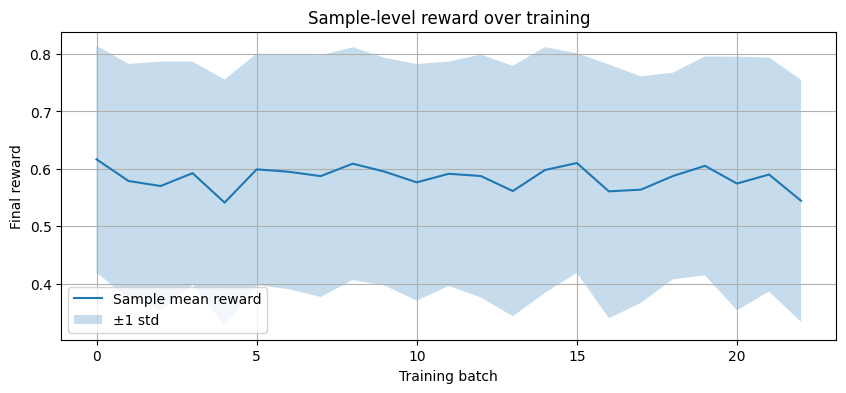

In [3]:
# ==========================================
# Cell 1: Sample-level reward mean & variance
# ==========================================
# 作用：
#   检查“真正参与 PPO 更新的 reward”在训练过程中发生了什么。
#
# 为什么重要：
#   - PPO/GRPO 实际优化的是 sample-level reward
#   - 只看 group mean 会掩盖 group 内 collapse
#
# 重点关注：
#   - mean 是否下降
#   - std 是否同时下降（variance minimization 的关键特征）

plt.figure(figsize=(10,4))

# sample-level reward 的均值
plt.plot(
    df_batch["reward/sample_mean_valid"],
    label="Sample mean reward"
)

# sample-level reward 的 ±1 std 区间
plt.fill_between(
    df_batch.index,
    df_batch["reward/sample_mean_valid"] - df_batch["reward/sample_std_valid"],
    df_batch["reward/sample_mean_valid"] + df_batch["reward/sample_std_valid"],
    alpha=0.25,
    label="±1 std"
)

plt.xlabel("Training batch")
plt.ylabel("Final reward")
plt.title("Sample-level reward over training")
plt.legend()
plt.grid(True)
plt.show()


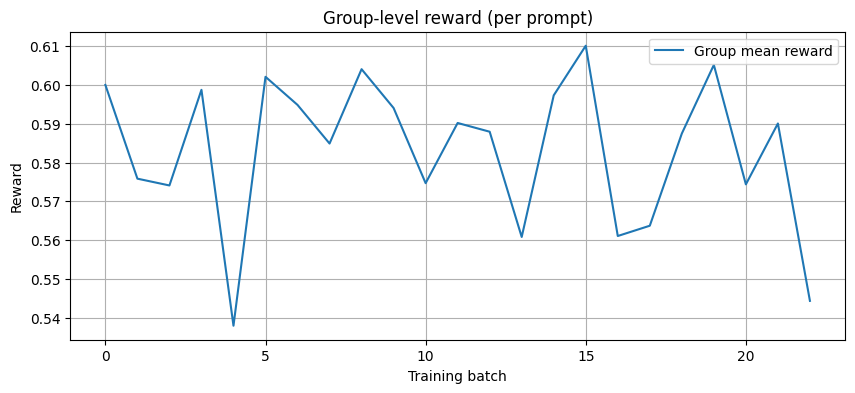

In [4]:
# ======================================
# Cell 2: Group-level (prompt-level) reward
# ======================================
# 作用：
#   查看“每个 research goal / prompt 的平均 reward”是否在变。
#
# 为什么要看：
#   - 如果 group mean 稳定，但 sample mean 在下降
#     => collapse 发生在 group 内部（非常常见、也最危险）
#
# 注意：
#   这是 group-level 的统计，不是 PPO 真正看到的信号。

plt.figure(figsize=(10,4))
plt.plot(
    df_batch["reward/group_mean_valid"],
    label="Group mean reward"
)
plt.xlabel("Training batch")
plt.ylabel("Reward")
plt.title("Group-level reward (per prompt)")
plt.legend()
plt.grid(True)
plt.show()


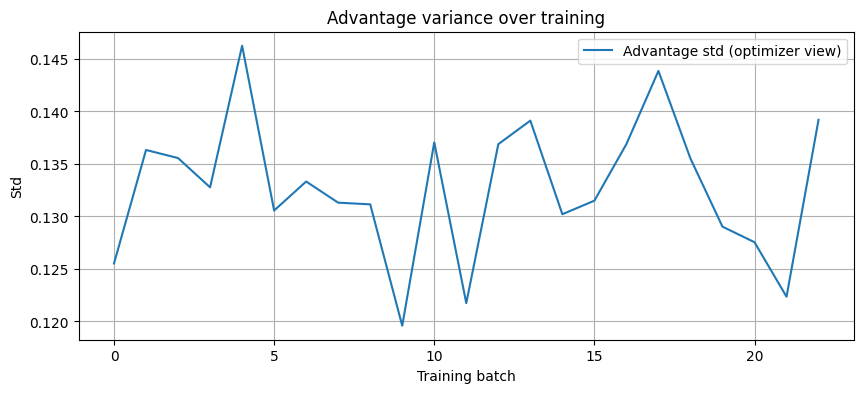

In [5]:
# =========================================
# Cell 3: Advantage variance (optimizer view)
# =========================================
# 作用：
#   检查 PPO / GRPO 的“梯度信号方差”是否在被主动压缩。
#
# 为什么这是最重要的图：
#   - PPO 更新 ∝ advantage × logprob
#   - advantage 的方差下降 = 优化器更偏好“低风险、稳定策略”
#
# 结论依据：
#   advantage_std 持续下降 + reward 下降
#   => variance minimization（不是 bug，是算法行为）

plt.figure(figsize=(10,4))
plt.plot(
    df_batch["advantage_std"],
    label="Advantage std (optimizer view)"
)
plt.xlabel("Training batch")
plt.ylabel("Std")
plt.title("Advantage variance over training")
plt.legend()
plt.grid(True)
plt.show()


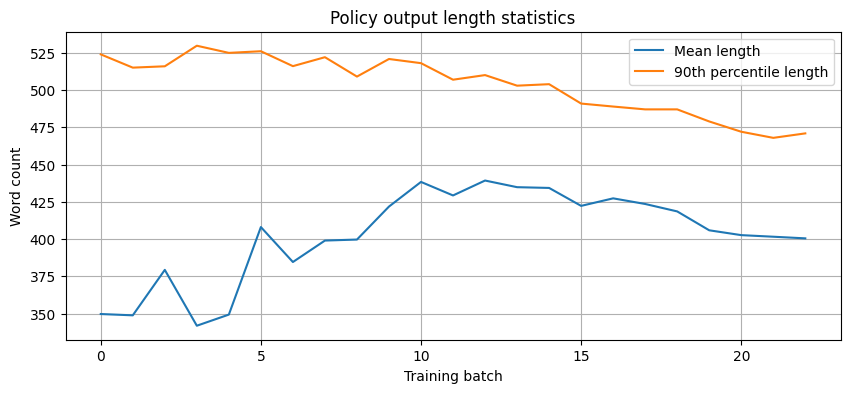

In [6]:
# ===================================
# Cell 4: Policy output length dynamics
# ===================================
# 作用：
#   检查模型是否通过“缩短输出”来降低 reward / gradient 方差。
#
# 为什么要看 p90：
#   - mean 会被短模板拉低
#   - p90 反映“长输出能力是否还在”
#
# 风险信号：
#   mean ↓ + p90 ↓ => 整体模板化（高风险）

plt.figure(figsize=(10,4))

plt.plot(
    df_batch["length_mean"],
    label="Mean length"
)

plt.plot(
    df_batch["length_p90"],
    label="90th percentile length"
)

plt.xlabel("Training batch")
plt.ylabel("Word count")
plt.title("Policy output length statistics")
plt.legend()
plt.grid(True)
plt.show()


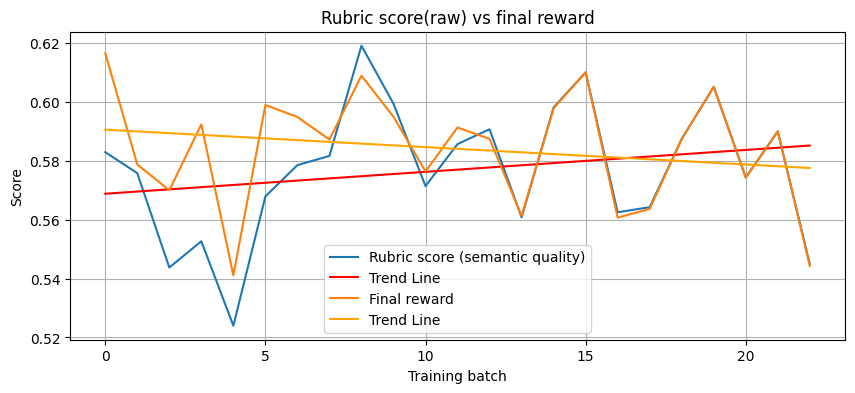

0.0007446302847967255 0.5688694317740679
-0.0005919596937590404 0.5906443738512807


In [7]:
# =================================================
# Cell 5: Rubric score vs final reward (root cause)
# =================================================
# 作用：
#   将“语义质量（rubric）”与“最终 reward”直接对照。
#
# 为什么必须看：
#   final_reward = rubric_score - format_penalty
#   如果不拆开，你根本不知道 reward 下降来自哪里。
#
# 判断规则：
#   - rubric ↓, reward ↓ => 语义能力退化
#   - rubric 稳, reward ↓ => penalty / reward design 问题
#   - rubric ↓, reward 稳 => reward hacking（最危险）

m_1, b_1 = np.polyfit(df_batch["rubric/sample_mean_all"].index, df_batch["rubric/sample_mean_all"], 1)
m_2, b_2 = np.polyfit(df_batch["reward/sample_mean_valid"].index, df_batch["reward/sample_mean_valid"], 1)


plt.figure(figsize=(10,4))

plt.plot(
    df_batch["rubric/sample_mean_all"],
    label="Rubric score (semantic quality)"
)


plt.plot(df_batch["rubric/sample_mean_all"].index, m_1*df_batch["rubric/sample_mean_all"].index + b_1, color='red', label='Trend Line')

plt.plot(
    df_batch["reward/sample_mean_valid"],
    label="Final reward"
)

plt.plot(df_batch["reward/sample_mean_valid"].index, m_2*df_batch["reward/sample_mean_valid"].index + b_2, color='orange', label='Trend Line')

plt.xlabel("Training batch")
plt.ylabel("Score")
plt.title("Rubric score(raw) vs final reward")
plt.legend()
plt.grid(True)
plt.show()

print(m_1, b_1)
print(m_2, b_2)


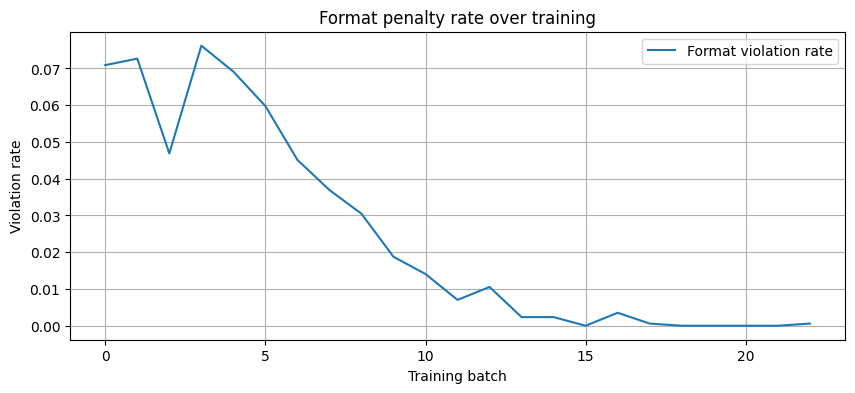

In [8]:
# =====================================
# Cell 6: Format violation rate analysis
# =====================================
# 作用：
#   检查 reward 变化是否主要由 format penalty 导致。
#
# 关键判断：
#   - format_rate → 0，但 reward 仍下降
#     => 不是格式问题，是策略选择问题（variance minimization）

plt.figure(figsize=(10,4))
plt.plot(
    df_batch["format_rate"],
    label="Format violation rate"
)
plt.xlabel("Training batch")
plt.ylabel("Violation rate")
plt.title("Format penalty rate over training")
plt.legend()
plt.grid(True)
plt.show()


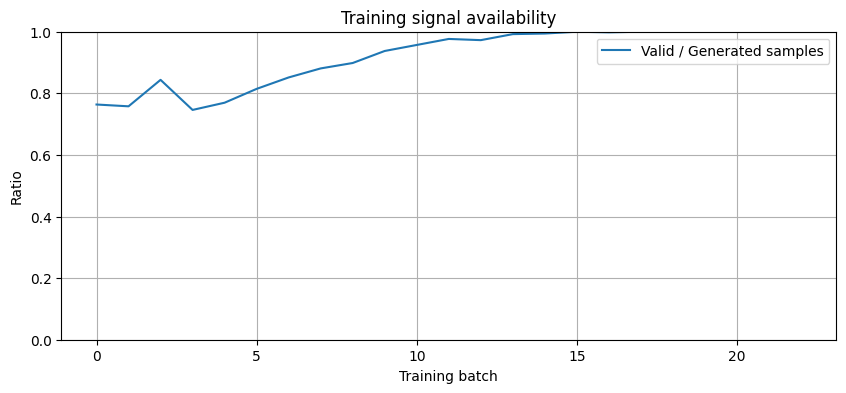

In [9]:
# =====================================
# Cell 7: Training signal availability
# =====================================
# 作用：
#   检查是否因为过滤过严，导致 PPO 没有足够样本学习。
#
# 指标：
#   samples_valid / samples_total
#
# 结论：
#   - ratio ↓ => signal starvation
#   - ratio 稳 => 问题不在样本数量

valid_ratio = df_batch["samples/valid"] / df_batch["samples/generated"]

plt.figure(figsize=(10,4))
plt.plot(
    valid_ratio,
    label="Valid / Generated samples"
)
plt.xlabel("Training batch")
plt.ylabel("Ratio")
plt.title("Training signal availability")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# =====================================
# Cell 8: Inspect failure samples
# =====================================
# 作用：
#   直接查看“最差样本”和“异常样本”，做定性判断。
#
# 这是所有统计图的补充，非常重要。

# 最低 reward 的样本
df_samples.nsmallest(5, "final_reward")[
    ["batch_idx", "final_reward", "rubric_score", "format_penalty", "word_count"]
]


,batch_idx,final_reward,rubric_score,format_penalty,word_count
2029,5,-0.300000,0.000000,0.3,3312
5694,12,-0.300000,0.000000,0.3,3322
7757,16,-0.300000,0.000000,0.3,2951
7723,16,-0.197143,0.102857,0.3,559
5642,12,-0.008571,0.291429,0.3,989


In [11]:
# =====================================
# Cell 9: Automatic diagnosis summary
# =====================================
# 作用：
#   用最近 N 个 batch 的趋势，给出一个自动判断。
#
# 这是一个“辅助工具”，不是最终裁决。

def diagnose_training(df_batch, window=20):
    tail = df_batch.tail(window)

    reward_trend = tail["reward/sample_mean_valid"].iloc[-1] - tail["reward/sample_mean_valid"].iloc[0]
    adv_trend = tail["advantage_std"].iloc[-1] - tail["advantage_std"].iloc[0]
    len_trend = tail["length_p90"].iloc[-1] - tail["length_p90"].iloc[0]

    print("=== Automatic Diagnosis (last {} batches) ===".format(window))
    print(f"Reward trend:        {reward_trend:.4f}")
    print(f"Advantage std trend: {adv_trend:.4f}")
    print(f"Length p90 trend:    {len_trend:.1f}")

    if reward_trend < 0 and adv_trend < 0 and len_trend < 0:
        print("⚠️ Likely VARIANCE MINIMIZATION / REWARD HACKING")
    elif reward_trend < 0 and adv_trend > 0:
        print("⚠️ Reward noise / grader instability")
    elif reward_trend > 0:
        print("✅ Training progressing normally")
    else:
        print("❓ Mixed signals, inspect manually")

diagnose_training(df_batch)


=== Automatic Diagnosis (last 20 batches) ===
Reward trend:        -0.0481
Advantage std trend: 0.0064
Length p90 trend:    -58.8
⚠️ Reward noise / grader instability



        DESIDERATA SCORE DISTRIBUTION

Desideratum 1
Mean: 1.8897
Std:  0.9987
Distribution:
  0: 14103
  1: 18259
  2: 41269
  3: 34537
  4: 0
  5: 0
  6: 0
  7: 0
  8: 0
  9: 0

Desideratum 2
Mean: 1.4183
Std:  0.8802
Distribution:
  0: 14108
  1: 49346
  2: 30077
  3: 14637
  4: 0
  5: 0
  6: 0
  7: 0
  8: 0
  9: 0

Desideratum 3
Mean: 1.4700
Std:  0.9114
Distribution:
  0: 14533
  1: 45179
  2: 31541
  3: 16915
  4: 0
  5: 0
  6: 0
  7: 0
  8: 0
  9: 0

Desideratum 4
Mean: 1.8881
Std:  0.9689
Distribution:
  0: 12658
  1: 19528
  2: 43244
  3: 32738
  4: 0
  5: 0
  6: 0
  7: 0
  8: 0
  9: 0

Desideratum 5
Mean: 2.0934
Std:  1.0137
Distribution:
  0: 12292
  1: 14120
  2: 32949
  3: 48807
  4: 0
  5: 0
  6: 0
  7: 0
  8: 0
  9: 0

Desideratum 6
Mean: 2.2033
Std:  1.1022
Distribution:
  0: 14477
  1: 13507
  2: 15730
  3: 64454
  4: 0
  5: 0
  6: 0
  7: 0
  8: 0
  9: 0

Desideratum 7
Mean: 2.3435
Std:  1.0039
Distribution:
  0: 10737
  1: 10104
  2: 18598
  3: 68729
  4: 0
  5: 0
  

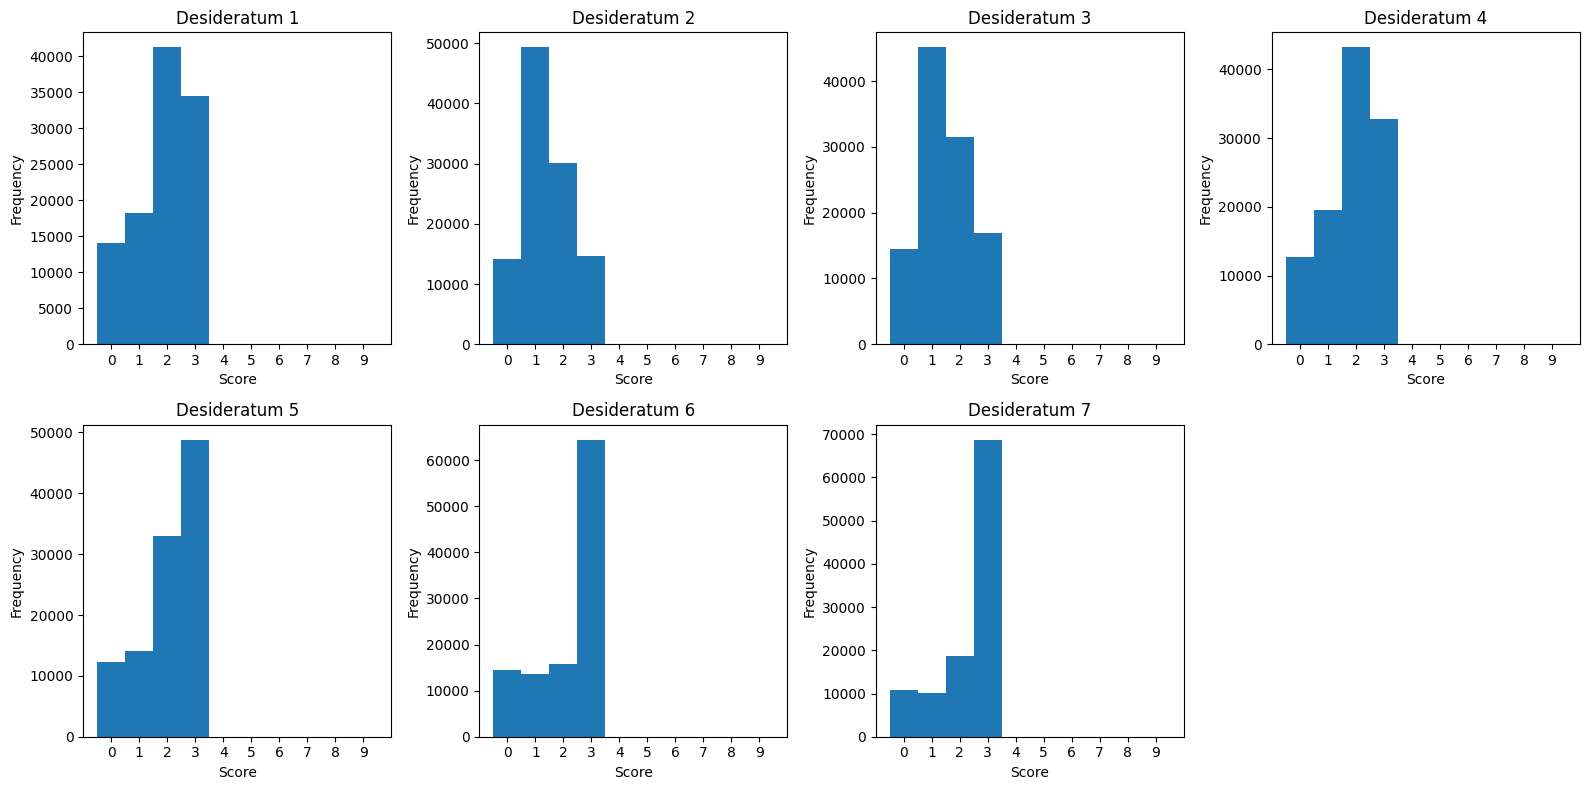

In [12]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# 🔧 修改这里
# ============================================================
LOG_PATH = sample_log_path


# ============================================================
# XML 解析
# ============================================================

def extract_item_desiderata_levels(xml_text):
    """
    Extract desiderata levels per rubric item.
    Returns:
        np.ndarray of shape (num_items, 7)
    """
    item_blocks = re.findall(
        r"<item\s+num=.*?>.*?</item>",
        xml_text,
        flags=re.DOTALL
    )

    all_items = []

    for item_xml in item_blocks:
        levels = re.findall(r"<level>(\d+)</level>", item_xml)
        levels = [int(l) for l in levels if l.isdigit()]

        if len(levels) < 7:
            levels = levels + [0] * (7 - len(levels))
        levels = levels[:7]

        all_items.append(levels)

    if not all_items:
        return None

    return np.array(all_items)


# ============================================================
# 读取日志
# ============================================================

all_levels = []

with open(LOG_PATH, "r") as f:
    for line in f:
        data = json.loads(line)
        xml_text = data.get("grader_output", "")
        item_levels = extract_item_desiderata_levels(xml_text)

        if item_levels is not None:
            all_levels.append(item_levels)

if not all_levels:
    raise ValueError("No desiderata data found in logs.")

# concatenate all rubric items across all samples
all_levels = np.concatenate(all_levels, axis=0)

print("\n====================================================")
print("        DESIDERATA SCORE DISTRIBUTION")
print("====================================================")

overall_means = []

for d in range(7):
    scores = all_levels[:, d]

    mean = np.mean(scores)
    std = np.std(scores)

    overall_means.append(mean)

    print(f"\nDesideratum {d+1}")
    print(f"Mean: {mean:.4f}")
    print(f"Std:  {std:.4f}")

    # frequency distribution 0–9
    hist = {i: 0 for i in range(10)}
    for s in scores:
        hist[int(s)] += 1

    print("Distribution:")
    for k in range(10):
        print(f"  {k}: {hist[k]}")

print("\n----------------------------------------------------")
print("Overall Mean Across 7 Desiderata:", np.mean(overall_means))
print("----------------------------------------------------")


# ============================================================
# 画直方图
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for d in range(7):
    axes[d].hist(all_levels[:, d], bins=np.arange(11)-0.5)
    axes[d].set_title(f"Desideratum {d+1}")
    axes[d].set_xticks(range(10))
    axes[d].set_xlabel("Score")
    axes[d].set_ylabel("Frequency")

axes[-1].axis("off")  # last empty subplot

plt.tight_layout()
plt.show()


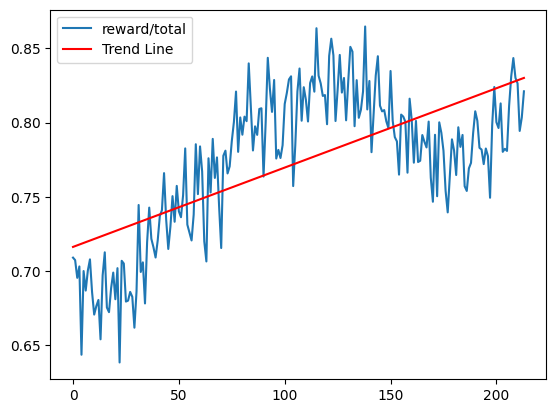

Total training time: 64505.7539896965 seconds
Average time per step: 301.4287569611986 seconds
0.0005348389398247868 0.7161881867917632


In [13]:
#ai co-scientist result
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
metrics_path = "/home/silas/co-scientist-project/runs/2026/2/std_stand+band_bonus/9(ml)/metrics.jsonl"
df = pd.read_json(metrics_path, lines=True)

m, b = np.polyfit(df.index, df["reward/total"], 1)

plt.plot(df["reward/total"], label="reward/total")
plt.plot(df.index, m*df.index + b, color='red', label='Trend Line')
plt.legend()
plt.show()


total_time = sum(df["time/total"])
print(f"Total training time: {total_time} seconds")
print(f"Average time per step: {total_time/len(df)} seconds")

print(m,b)